# File 2: Estimation on Real Data

Estimate the gender manager gap model using the Veneto employer-employee register.

All rates are **annual**.

**Steps:**
1. Load data
2. Prepare variables
3. Estimate $\delta$, $\delta_M$ and implicit unemployment
4. Compute observed moments
5. Set literature parameters
6. Solve for $\theta^*$
7. Calibrate $\bar{\lambda}_m^M$ and $\bar{\lambda}_f^M$
8. Present results

## Section 1: Imports

In [1]:
!pip install pyfixest

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import pyfixest as pf


plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.labelsize':    13,
    'axes.titlesize':    14,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'legend.fontsize':   11,
    'font.family':       'serif',
    'figure.dpi':        120,
})
print('Imports loaded.')

Imports loaded.


## Section 2: Load Data

Adjust the file path and variable names if needed.

In [2]:
# ── Load your data file here ──────────────────────────────────
# Adjust path and format as needed
df = pd.read_stata('/Users/majarath/Desktop/Labor /Kodefiler /Veneto_panel_1984_2001.dta')

print('Data loaded.')
print(f'Observations: {len(df):,}')
print(f'Columns: {list(df.columns)}')


/var/folders/j9/hs1nsvh14qj33c2f34j0g8jc0000gn/T/ipykernel_71940/1444501015.py:3: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata('/Users/majarath/Desktop/Labor /Kodefiler /Veneto_panel_1984_2001.dta')


Data loaded.
Observations: 24,217,162
Columns: ['id', 'year', 'firmid', 'gior_r', 'retrib03', 'total_jobs_in_year', 'daily_wage', 'log_dailywages', 'weeks', 'weekly_wage', 'log_weekly_wage', 'occupation', 'com_firm', 'prov', 'cod_com_firm', 'ateco81', 'firmbirth', 'firmdeath', 'publicsector', 'sec1', 'prov_birth', 'birth', 'male', 'foreign', 'age']


### Definerer manager dummy og firm age 

In [3]:
 #── Manager dummy ─────────────────────────────────────────────
df['manager'] = (df['occupation'] == 'Manager').astype(int)

print('=== Data Overview ===')
print(f'Observations:          {len(df):,}')
print(f'Unique persons (id):   {df["id"].nunique():,}')
print(f'Unique firms:          {df["firmid"].nunique():,}')
print(f'Years:                 {df["year"].min()} - {df["year"].max()}')
print(f'Men:                   {df["male"].sum():,}')
print(f'Women:                 {(1-df["male"]).sum():,}')
print(f'\nManager share — men:   {df[df["male"]==1]["manager"].mean():.4f}')
print(f'Manager share — women: {df[df["male"]==0]["manager"].mean():.4f}')
print(f'Raw gender gap:        {df[df["male"]==1]["manager"].mean() - df[df["male"]==0]["manager"].mean():.4f}')

=== Data Overview ===
Observations:          24,217,162
Unique persons (id):   2,767,318
Unique firms:          677,221
Years:                 1984 - 2001
Men:                   14,648,755.0
Women:                 9,568,338.0

Manager share — men:   0.0181
Manager share — women: 0.0029
Raw gender gap:        0.0153


In [4]:
# variables gennemsnit før rensning
print(f'Før rensning — observationer:        {len(df):,}')
print(f'Før rensning — andel mænd:           {df["male"].mean():.4f}')
print(f'Før rensning — andel managers:       {df["manager"].mean():.4f}')
print(f'Før rensning — manager andel mænd:   {df[df["male"]==1]["manager"].mean():.4f}')
print(f'Før rensning — manager andel kvinder:{df[df["male"]==0]["manager"].mean():.4f}')
print(f'Før rensning — gns. alder:           {df["age"].mean():.2f}')
print(f'Før rensning — gns. år i datasæt:    {df.groupby("id")["year"].count().mean():.2f}')
print(f'Før rensning — andel blue collar:     {(df["occupation"]=="Blue Collar").mean():.4f}')
print(f'Før rensning — andel white collar:    {(df["occupation"]=="White Collar").mean():.4f}')
print(f'Før rensning — andel apprentice:      {(df["occupation"]=="Apprentice").mean():.4f}')
print(f'Før rensning — gns. antal jobs/år:    {df["total_jobs_in_year"].mean():.4f}')
print(f'Før rensning — gns. løn (retrib03):  {df["retrib03"].mean():.2f}')



Før rensning — observationer:        24,217,162
Før rensning — andel mænd:           0.6049
Før rensning — andel managers:       0.0121
Før rensning — manager andel mænd:   0.0181
Før rensning — manager andel kvinder:0.0029
Før rensning — gns. alder:           33.31
Før rensning — gns. år i datasæt:    8.75
Før rensning — andel blue collar:     0.6137
Før rensning — andel white collar:    0.2993
Før rensning — andel apprentice:      0.0748
Før rensning — gns. antal jobs/år:    1.2090
Før rensning — gns. løn (retrib03):  30349.01


## Section 3: Data Preparation

In [6]:
# ── Rens datasættet ───────────────────────────────────────────
# Fjern manglende værdier i nøglevariable
df = df.dropna(subset=['id', 'year', 'firmid', 'male', 'occupation', 
                        'retrib03',])

# Fjern nuller i løn
df = df[df['retrib03'] > 500]


print(f'Observationer efter rensning: {len(df):,}')

#sletter personer under 13 år
df = df[(df['age'] >= 13) & (df['age'] <= 65)]

#fjerner variable der ikke bruges 
keep_cols = ['id', 'year', 'firmid', 'male', 'manager', 
             'retrib03',
             'occupation', 'age', 'gior_r','total_jobs_in_year']

df = df[keep_cols]
print(f'Kolonner beholdt: {list(df.columns)}')
print(f'Hukommelse: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')



Observationer efter rensning: 23,971,936
Kolonner beholdt: ['id', 'year', 'firmid', 'male', 'manager', 'retrib03', 'occupation', 'age', 'gior_r', 'total_jobs_in_year']
Hukommelse: 1.17 GB


In [7]:
#── Efter rensning ────────────────────────────────────────────
print('\n=== Efter rensning ===')
print(f'Observationer:              {len(df):,}')
print(f'Andel mænd:                 {df["male"].mean():.4f}')
print(f'Andel managers:             {df["manager"].mean():.4f}')
print(f'Manager andel mænd:         {df[df["male"]==1]["manager"].mean():.4f}')
print(f'Manager andel kvinder:      {df[df["male"]==0]["manager"].mean():.4f}')
print(f'Gns. alder:                 {df["age"].mean():.2f}')
print(f'Andel blue collar:          {(df["occupation"]=="Blue Collar").mean():.4f}')
print(f'Andel white collar:         {(df["occupation"]=="White Collar").mean():.4f}')
print(f'Andel apprentice:           {(df["occupation"]=="Apprentice").mean():.4f}')
print(f'Gns. antal jobs/år:         {df["total_jobs_in_year"].mean():.4f}')
print(f'Gns. løn (retrib03):        {df["retrib03"].mean():.2f}')






=== Efter rensning ===
Observationer:              23,971,936
Andel mænd:                 0.6050
Andel managers:             0.0122
Manager andel mænd:         0.0183
Manager andel kvinder:      0.0029
Gns. alder:                 33.27
Andel blue collar:          0.6135
Andel white collar:         0.2995
Andel apprentice:           0.0748
Gns. antal jobs/år:         1.2098
Gns. løn (retrib03):        30619.54


### Definer df_est

In [8]:
## definer df_est 
df_est = (df[df['retrib03'].notna() & (df['retrib03'] > 0)]
          .sort_values(['id', 'year', 'gior_r'], ascending=[True, True, False])
          .drop_duplicates(['id', 'year'], keep='first')
          .copy())
df_est['log_wage'] = np.log(df_est['retrib03'])

print(f'Observationer: {len(df_est):,}')
print(f'Unikke individer: {df_est["id"].nunique():,}')




Observationer: 23,971,936
Unikke individer: 2,738,925


## section 4: Estimate $\delta$, $\delta_M$, job finding rate and Implicit Unemployment

**Separation rate**: Annual separation rates mean number of job separations 


In [9]:
# ── Separationsrater ──────────────────────────────────────────
primary = (df_est.sort_values(['id', 'year', 'gior_r'], ascending=[True, True, False])
                 .drop_duplicates(['id', 'year'], keep='first')
                 [['id', 'year', 'firmid', 'manager', 'male']])

primary = primary.sort_values(['id', 'year'])
primary['year_next'] = primary.groupby('id')['year'].shift(-1)

primary['separated_to_u'] = (
    (primary['year_next'] - primary['year'] > 1) |
    primary['year_next'].isna()
)

# Ekskluder det sidste år i panelet (højrecensurerede observationer):
# arbejdere observeret i 2001 har year_next=NaN men vi ved ikke om de separerede —
# data stopper bare. Disse tæller ikke med i nævneren.
max_year     = primary['year'].max()
not_censored = primary['year'] < max_year

delta_est     = primary[not_censored & (primary['manager']==0)]['separated_to_u'].mean()
delta_M_m_est = primary[not_censored & (primary['manager']==1) & (primary['male']==1)]['separated_to_u'].mean()
delta_M_f_est = primary[not_censored & (primary['manager']==1) & (primary['male']==0)]['separated_to_u'].mean()

print(f'=== Separationsrater (ekskl. {int(max_year)}) ===')
print(f'δ   (normal):          {delta_est:.4f}')
print(f'δ^m mænd (manager):    {delta_M_m_est:.4f}')
print(f'δ^m kvinder (manager): {delta_M_f_est:.4f}')

del primary

=== Separationsrater (ekskl. 2001) ===
δ   (normal):          0.0940
δ^m mænd (manager):    0.0866
δ^m kvinder (manager): 0.1355


## Section 5: Observed Moments

In [10]:
# ============================================================
# Section 5: Observerede momenter
# ============================================================
m_m_data = df_est[df_est['male']==1]['manager'].mean()
m_f_data = df_est[df_est['male']==0]['manager'].mean()

w_E_m = df_est[(df_est['male']==1) & (df_est['manager']==0)]['retrib03'].mean()
w_E_f = df_est[(df_est['male']==0) & (df_est['manager']==0)]['retrib03'].mean()
w_M_m = df_est[(df_est['male']==1) & (df_est['manager']==1)]['retrib03'].mean()
w_M_f = df_est[(df_est['male']==0) & (df_est['manager']==1)]['retrib03'].mean()

share_male = df_est['male'].mean()
w_E_avg    = share_male * w_E_m + (1 - share_male) * w_E_f
w_M_avg    = share_male * w_M_m + (1 - share_male) * w_M_f

# Niveau-lønner til DMP-modellen
w_E_m_lev = df_est[(df_est['male']==1) & (df_est['manager']==0)]['retrib03'].mean()
w_E_f_lev = df_est[(df_est['male']==0) & (df_est['manager']==0)]['retrib03'].mean()
w_M_m_lev = df_est[(df_est['male']==1) & (df_est['manager']==1)]['retrib03'].mean()
w_M_f_lev = df_est[(df_est['male']==0) & (df_est['manager']==1)]['retrib03'].mean()
w_E_avg_lev = share_male * w_E_m_lev + (1 - share_male) * w_E_f_lev
manager_male_share = (m_m_data * share_male) / (m_m_data * share_male + m_f_data * (1 - share_male))
w_M_avg_lev = manager_male_share * w_M_m_lev + (1 - manager_male_share) * w_M_f_lev


print(f'\n=== Observerede momenter ===')
print(f'Manager-andel mænd:    {m_m_data:.4f}')
print(f'Manager-andel kvinder: {m_f_data:.4f}')
print(f'Normal løn mænd (niveau): {w_E_m:.0f} EUR')
print(f'Normal løn kvinder (niveau): {w_E_f:.0f} EUR')
print(f'Manager løn mænd (niveau): {w_M_m:.0f} EUR')
print(f'Manager løn kvinder (niveau): {w_M_f:.0f} EUR')
print(f'Normal løn mænd (niveau): {w_E_m_lev:.0f} EUR')
print(f'Normal løn kvinder (niveau): {w_E_f_lev:.0f} EUR')
print(f'Manager løn mænd (niveau): {w_M_m_lev:.0f} EUR')
print(f'Manager løn kvinder (niveau): {w_M_f_lev:.0f} EUR')


=== Observerede momenter ===
Manager-andel mænd:    0.0183
Manager-andel kvinder: 0.0029
Normal løn mænd (niveau): 33205 EUR
Normal løn kvinder (niveau): 23551 EUR
Manager løn mænd (niveau): 137575 EUR
Manager løn kvinder (niveau): 88800 EUR
Normal løn mænd (niveau): 33205 EUR
Normal løn kvinder (niveau): 23551 EUR
Manager løn mænd (niveau): 137575 EUR
Manager løn kvinder (niveau): 88800 EUR


## Section 6: litterature parameters 

All parameters are **annual** to match the yearly time unit of the data.

**Parameter sources:**
- $\eta = 0.5$: Petrongolo & Pissarides (2001), "Looking into the Black Box: A Survey of the Matching Function", *Journal of Economic Literature*
- $\beta = 0.5$: Hosios (1990), "On the Efficiency of Matching and Related Models of Search and Unemployment", *Review of Economic Studies*
- $r = 0.02$: Standard annual discount rate, see Mortensen & Pissarides (1994), "Job Creation and Job Destruction in the Theory of Unemployment", *Review of Economic Studies*: 
- $\mu = 1.0$: Normalisation of the matching function, following the standard convention in Pissarides (2000), "Equilibrium Unemployment Theory", *MIT Press*

In [20]:
# ============================================================
# Section 6: Litteraturparametre og outside option
# ============================================================
eta  = 0.5
beta = 0.5
r    = 0.02
mu   = 1.0
k    = 0.2 * w_E_avg_lev   # vakanceomkostning = 20% af gns. løn (niveauer)
b    = 0.4 * w_E_avg_lev   # dagpenge = 40% erstatningsrate (niveauer)

print(f'\n=== Litteraturparametre ===')
print(f'mu={mu}, eta={eta}, beta={beta}, r={r}')
print(f'k={k:.2f} EUR, b={b:.2f} EUR')
print(f'Erstatningsrate: {b / w_E_avg_lev:.1%}')
print(f'Vacancy cost andel: {k / w_E_avg_lev:.1%}')


=== Litteraturparametre ===
mu=1.0, eta=0.5, beta=0.5, r=0.02
k=5878.42 EUR, b=11756.84 EUR
Erstatningsrate: 40.0%
Vacancy cost andel: 20.0%


## section 7: modelfunctions

In [22]:
# ============================================================
# Section 7: Modelfunktioner
# ============================================================
def f_theta(theta, mu):
    return mu * theta**(1 - eta)

def q_theta(theta, mu):
    return mu * theta**(-eta)

def steady_state_m(f, lam_m):
    A = f / (delta_est + lam_m)
    B = (lam_m / delta_M_m_est) * A
    u = 1.0 / (1.0 + A + B)
    return u, A * u, B * u

def steady_state_f(f, lam_f):
    A = f / (delta_est + lam_f)
    B = (lam_f / delta_M_f_est) * A
    u = 1.0 / (1.0 + A + B)
    return u, A * u, B * u

def compute_p_F(theta):
    """Back ud p_F fra Nash-lønnen givet theta."""
    return (w_E_avg_lev - (1 - beta) * b) / beta - k * theta

def compute_p_F_m(p_F, theta):
    """Back ud p_F^m fra manager Nash-lønnen."""
    w = (1 - beta) * b + beta * (p_F + k * theta)
    return (w_M_avg_lev - (1 - beta) * w) / beta

def solve_theta(lm, lf, mu):
    """Løs for θ* med kønssepareret F^e — firmaet kender ikke kønnet ved opslag."""
    def residual(theta):
        p_F_t   = compute_p_F(theta)
        p_F_m_t = compute_p_F_m(p_F_t, theta)
        w       = (1 - beta) * b + beta * (p_F_t + k * theta)
        F_m_m   = (1 - beta) * (p_F_m_t - w) / (r + delta_M_m_est)
        F_m_f   = (1 - beta) * (p_F_m_t - w) / (r + delta_M_f_est)
        F_e_m   = (p_F_t - w + lm * F_m_m) / (r + delta_est + lm)
        F_e_f   = (p_F_t - w + lf * F_m_f) / (r + delta_est + lf)
        lhs     = k / q_theta(theta, mu)
        rhs     = share_male * F_e_m + (1 - share_male) * F_e_f
        return lhs - rhs

    return fsolve(residual, x0=1.0)[0]


##  Section 8: Iterativ løsning 

In [29]:
# Section 8: Iterativ løsning
# ============================================================
def iterative_solve(tol=1e-8, max_iter=500):
    lm, lf  = 1e-4, 1e-5
    theta_i = 1.0
    rows    = []

    print(f'{"Iter":>5} {"θ*":>8} {"p_F":>8} {"p_F^m":>8} {"λ_m":>12} {"λ_f":>12} {"Δλ_m":>10} {"Δλ_f":>10}')
    print('-' * 80)

    for i in range(max_iter):
        # Trin 1: løs for ny theta med fast mu og konsistent p_F inde i residualet
        theta_new = solve_theta(lm, lf, mu)
        f_i       = f_theta(theta_new, mu)

        # p_F og p_F^m ved konvergeret theta (kun til rapportering)
        p_F   = compute_p_F(theta_new)
        p_F_m = compute_p_F_m(p_F, theta_new)

        # Trin 2: kalibrer lambda
        def model_gap(params):
            lbm = max(params[0], 1e-9)
            lbf = max(params[1], 1e-9)
            _, _, mm = steady_state_m(f_i, lbm)
            _, _, mf = steady_state_f(f_i, lbf)
            return [mm - m_m_data, mf - m_f_data]

        lm_new, lf_new = fsolve(model_gap, x0=[lm, lf])
        lm_new = max(lm_new, 1e-9)
        lf_new = max(lf_new, 1e-9)

        delta_lm = abs(lm_new - lm)
        delta_lf = abs(lf_new - lf)

        print(f'{i+1:>5} {theta_new:>8.4f} {p_F:>8.4f} {p_F_m:>8.4f} '
              f'{lm_new:>12.7f} {lf_new:>12.7f} '
              f'{delta_lm:>10.2e} {delta_lf:>10.2e}')

        if delta_lm < tol and delta_lf < tol and abs(theta_new - theta_i) < tol:
            print(f'\nKonvergeret efter {i+1} iterationer.')
            return theta_new, lm_new, lf_new, p_F, p_F_m

        lm, lf  = lm_new, lf_new
        theta_i = theta_new

        rows.append([i+1, theta_new, p_F, p_F_m, lm_new, lf_new, delta_lm, delta_lf])

        if delta_lm < tol and delta_lf < tol and abs(theta_new - theta_i) < tol:
            print(f'\nKonvergeret efter {i+1} iterationer.')
            iter_df = pd.DataFrame(rows, columns=['Iter', 'theta', 'p_F', 'p_F_m', 'lambda_m', 'lambda_f', 'delta_lm', 'delta_lf'])
            iter_df.to_csv('iterations.csv', index=False)
            return theta_new, lm_new, lf_new, p_F, p_F_m

        lm, lf  = lm_new, lf_new
        theta_i = theta_new

    print(f'\nAdvarsel: konvergerede ikke efter {max_iter} iterationer.')
    iter_df = pd.DataFrame(rows, columns=['Iter', 'theta', 'p_F', 'p_F_m', 'lambda_m', 'lambda_f', 'delta_lm', 'delta_lf'])
    iter_df.to_csv('iterations.csv', index=False)
    return theta_new, lm_new, lf_new, p_F, p_F_m

theta_star, lambda_m, lambda_f, p_F, p_F_m = iterative_solve()

 Iter       θ*      p_F    p_F^m          λ_m          λ_f       Δλ_m       Δλ_f
--------------------------------------------------------------------------------
    1   2.8189 30456.7255 236588.7548    0.0017027    0.0004165   1.60e-03   4.06e-04
    2   2.9891 29456.3266 236588.7548    0.0017001    0.0004158   2.66e-06   6.41e-07
    3   2.9888 29457.9710 236588.7548    0.0017001    0.0004158   4.18e-09   1.01e-09

Konvergeret efter 3 iterationer.


## Section 9

In [24]:
# Section 9: Resultater
# ============================================================
f_star = f_theta(theta_star, mu)
d      = -np.log(lambda_f / lambda_m)
w_star = (1 - beta) * b + beta * (p_F + k * theta_star)
w_m    = (1 - beta) * w_star + beta * p_F_m

_, _, mm_cal = steady_state_m(f_star, lambda_m)
_, _, mf_cal = steady_state_f(f_star, lambda_f)

print(f'\n=== Endelige parametre ===')
print(f'{"Parameter":<25} {"Værdi":>10} {"Kilde":>30}')
print('='*67)
for name, val, source in [
    ('mu',              mu,            'Normaliseret (Pissarides 2000)'),
    ('eta',             eta,           'Petrongolo & Pissarides'),
    ('beta',            beta,          'Hosios betingelse'),
    ('r',               r,             'Standard (årlig)'),
    ('k',               k,             'Pissarides (2009)'),
    ('b',               b,             '60% erstatningsrate'),
    ('delta',           delta_est,     'Estimeret fra data'),
    ('delta_M mænd',    delta_M_m_est, 'Estimeret fra data'),
    ('delta_M kvinder', delta_M_f_est, 'Estimeret fra data'),
    ('f* (job-finding)',f_star,        'Beregnet fra model'),
    ('p_F',             p_F,           'Beregnet fra Nash løn'),
    ('p_F^m',           p_F_m,         'Beregnet fra Nash løn'),
    ('theta*',          theta_star,    'Løst fra model'),
    ('w (normal)',      w_star,        'Nash løn'),
    ('w^m (manager)',   w_m,           'Nash løn'),
    ('lambda_m',        lambda_m,      'Kalibreret'),
    ('lambda_f',        lambda_f,      'Kalibreret'),
    ('d',               d,             'Beregnet'),
]:
    print(f'{name:<25} {val:>10.4f} {source:>30}')

print(f'\n=== Model vs. data ===')
print(f'  m_m: model={mm_cal:.4f}  data={m_m_data:.4f}')
print(f'  m_f: model={mf_cal:.4f}  data={m_f_data:.4f}')


=== Endelige parametre ===
Parameter                      Værdi                          Kilde
mu                            1.0000 Normaliseret (Pissarides 2000)
eta                           0.5000        Petrongolo & Pissarides
beta                          0.5000              Hosios betingelse
r                             0.0200               Standard (årlig)
k                          5878.4189              Pissarides (2009)
b                         11756.8378            60% erstatningsrate
delta                         0.0940             Estimeret fra data
delta_M mænd                  0.0866             Estimeret fra data
delta_M kvinder               0.1355             Estimeret fra data
f* (job-finding)              1.7288             Beregnet fra model
p_F                       29457.9684          Beregnet fra Nash løn
p_F^m                     236588.7548          Beregnet fra Nash løn
theta*                        2.9888                 Løst fra model
w (normal)         

## Section 10: Kontrafaktisk og løndekomponering 

In [25]:
# Section 10: Kontrafaktisk og løndekomponering
# ============================================================
_, _, mf_nodiscrim = steady_state_f(f_star, lambda_m)

w_f_obs     = (1 - m_f_data) * w_E_f + m_f_data * w_M_f
w_m_obs     = (1 - m_m_data) * w_E_m + m_m_data * w_M_m
raw_gap     = w_m_obs - w_f_obs
w_f_cf      = (1 - mf_nodiscrim) * w_E_f + mf_nodiscrim * w_M_f
gap_discrim = w_f_cf - w_f_obs
gap_rest    = raw_gap - gap_discrim

print(f'\n=== Løndekomponering ===')
print(f'Råt løngab:                        {raw_gap:.4f}')
print(f'Kontrafaktisk manager-andel (d=0): {mf_nodiscrim:.4f}')
print(f'Del forklaret af diskrimination:   {gap_discrim:.4f} ({gap_discrim/raw_gap:.1%})')
print(f'Resterende løngab:                 {gap_rest:.4f} ({gap_rest/raw_gap:.1%})')


=== Løndekomponering ===
Råt løngab:                        11369.9957
Kontrafaktisk manager-andel (d=0): 0.0117
Del forklaret af diskrimination:   577.1468 (5.1%)
Resterende løngab:                 10792.8489 (94.9%)


## Section 11: Plot

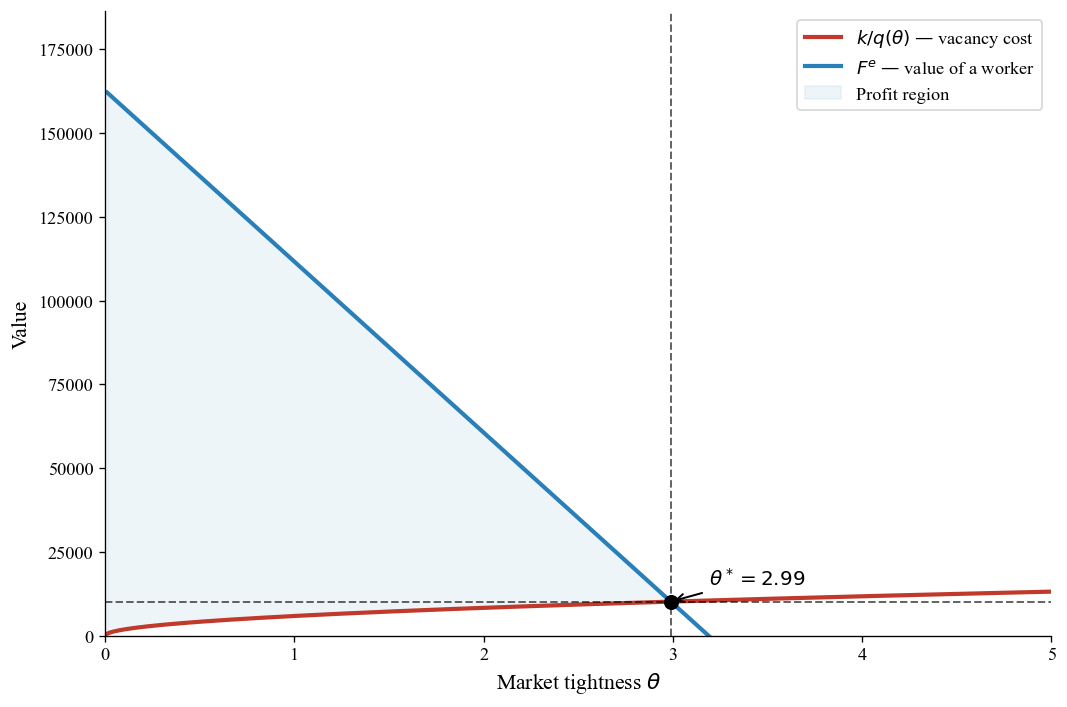

In [53]:
# Section 11: Job creation curve plot
# ============================================================
theta_vec    = np.linspace(0.01, 5.0, 300)
lambda_avg   = share_male * lambda_m + (1 - share_male) * lambda_f
lambda_m_avg = share_male * lambda_m
lambda_f_avg = (1 - share_male) * lambda_f

lhs_vec = k / q_theta(theta_vec, mu)
def rhs_func(t):
    p_F_t   = compute_p_F(t)
    p_F_m_t = compute_p_F_m(p_F_t, t)
    w_t     = (1 - beta) * b + beta * (p_F_t + k * t)
    F_m_m_t = (1 - beta) * (p_F_m_t - w_t) / (r + delta_M_m_est)
    F_m_f_t = (1 - beta) * (p_F_m_t - w_t) / (r + delta_M_f_est)
    F_e_m_t = (p_F_t - w_t + lambda_m * F_m_m_t) / (r + delta_est + lambda_m)
    F_e_f_t = (p_F_t - w_t + lambda_f * F_m_f_t) / (r + delta_est + lambda_f)
    return share_male * F_e_m_t + (1 - share_male) * F_e_f_t

rhs_vec = np.array([rhs_func(t) for t in theta_vec])

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(theta_vec, lhs_vec, color='#c0392b', lw=2.5, label='$k/q(\\theta)$ — vacancy cost')
ax.plot(theta_vec, rhs_vec, color='#2980b9', lw=2.5, label='$F^e$ — value of a worker')
ax.fill_between(theta_vec, lhs_vec, rhs_vec,
                where=(rhs_vec > lhs_vec),
                alpha=0.08, color='#2980b9', label='Profit region')

y_intersect = k / q_theta(theta_star, mu)
ax.axvline(theta_star, color='black', lw=1.2, ls='--', alpha=0.6)
ax.axhline(y_intersect, color='black', lw=1.2, ls='--', alpha=0.6)
ax.plot(theta_star, y_intersect, 'o', color='black', markersize=8, zorder=5)
ax.annotate(f'$\\theta^* = {theta_star:.2f}$',
            xy=(theta_star, y_intersect),
            xytext=(theta_star + 0.2, y_intersect + 5000),
            fontsize=12,
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax.set_xlabel('Market tightness $\\theta$', fontsize=13)
ax.set_ylabel('Value', fontsize=13)
ax.set_xlim(0, 5)
ax.set_ylim(0, max(lhs_vec.max(), rhs_vec.max()) * 1.15)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('job_creation_curve.pdf', bbox_inches='tight')
plt.show()

## Section 12: Kontrafaktisk plot 

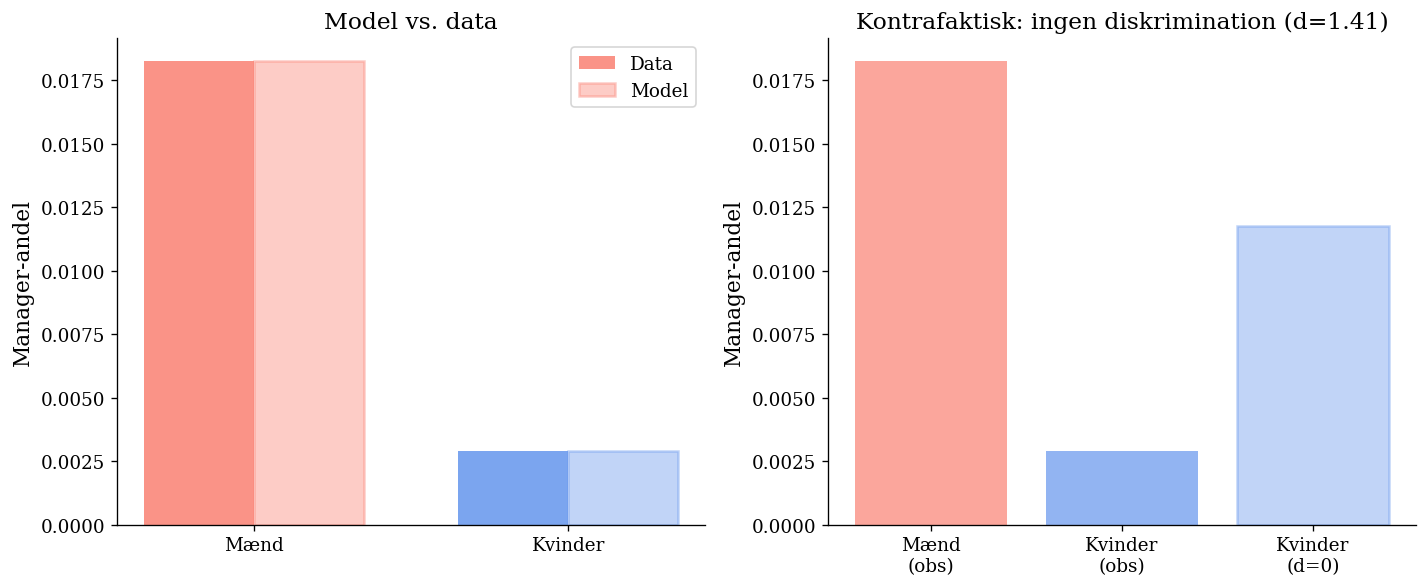

In [27]:
# Section 12: Kontrafaktisk plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x, w = np.arange(2), 0.35
axes[0].bar(x - w/2, [m_m_data, m_f_data], w,
            label='Data', color=['salmon', 'cornflowerblue'], alpha=0.85)
axes[0].bar(x + w/2, [mm_cal, mf_cal], w,
            label='Model', color=['salmon', 'cornflowerblue'], alpha=0.4,
            edgecolor=['salmon', 'cornflowerblue'], linewidth=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Mænd', 'Kvinder'])
axes[0].set_ylabel('Manager-andel')
axes[0].set_title('Model vs. data')
axes[0].legend()

categories = ['Mænd\n(obs)', 'Kvinder\n(obs)', 'Kvinder\n(d=0)']
values     = [m_m_data, m_f_data, mf_nodiscrim]
bars       = axes[1].bar(categories, values,
                         color=['salmon', 'cornflowerblue', 'cornflowerblue'],
                         alpha=0.7)
bars[2].set_edgecolor('cornflowerblue')
bars[2].set_linewidth(1.5)
bars[2].set_alpha(0.4)
axes[1].set_ylabel('Manager-andel')
axes[1].set_title(f'Kontrafaktisk: ingen diskrimination (d={d:.2f})')

plt.tight_layout()
plt.show()

## Kontrafaktisk plot 2

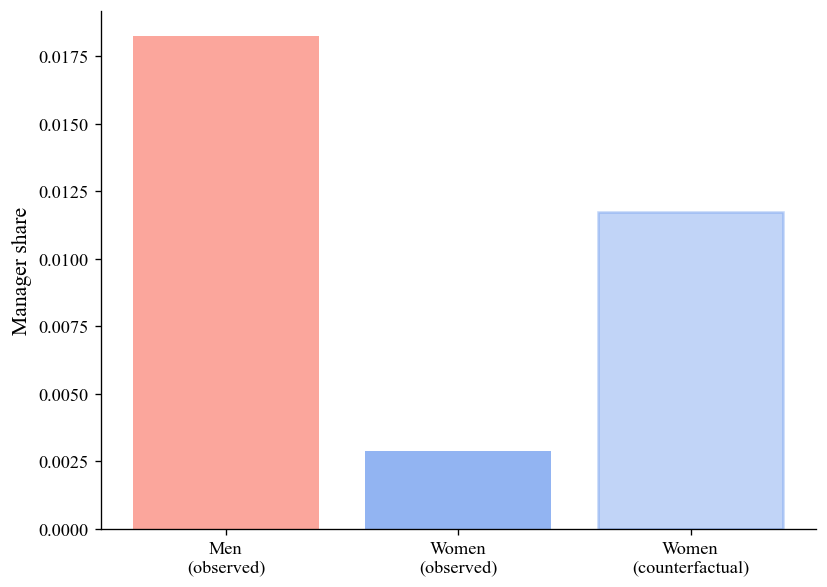

In [46]:
fig, ax = plt.subplots(figsize=(7, 5))

categories = ['Men\n(observed)', 'Women\n(observed)', 'Women\n(counterfactual)']
values     = [m_m_data, m_f_data, mf_nodiscrim]
colors     = ['salmon', 'cornflowerblue', 'cornflowerblue']
bars       = ax.bar(categories, values, color=colors, alpha=0.7)
bars[2].set_edgecolor('cornflowerblue')
bars[2].set_linewidth(1.5)
bars[2].set_alpha(0.4)
ax.set_ylabel('Manager share')

plt.tight_layout()
plt.savefig('counterfactual_managers.pdf', bbox_inches='tight')
plt.show()


## Counterfactual wage gap vs raw wage gap


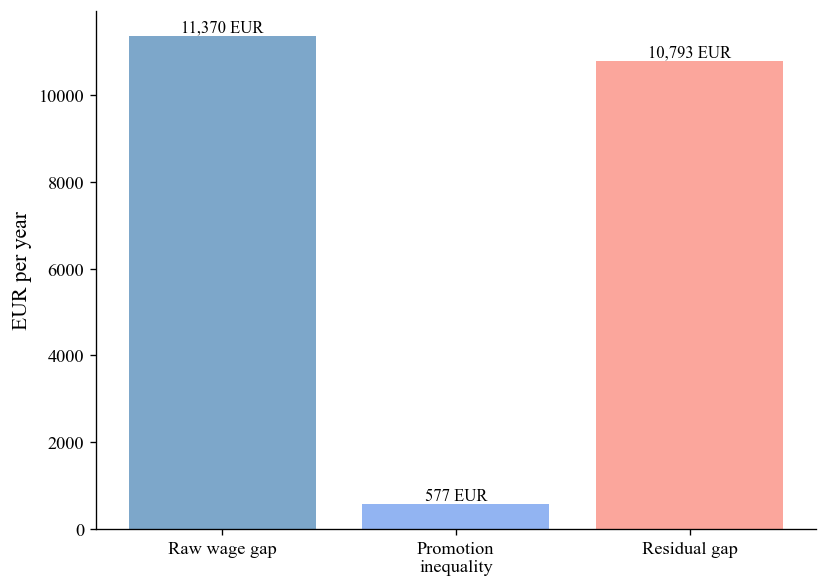

In [ ]:
#beregning af råt løngab (før dekomponering)
#w_m_obs = (1 - m_m_data) * w_E_m + m_m_data * w_M_m  # vægtet gns. mandeløn
#w_f_obs = (1 - m_f_data) * w_E_f + m_f_data * w_M_f  # vægtet gns. kvindeløn
#raw_gap = w_m_obs - w_f_obs  # = 11,370 EUR

#beregning af kontrafaktisk kvindeløn hvis λ_f = λ_m 
#w_f_cf      = (1 - mf_nodiscrim) * w_E_f + mf_nodiscrim * w_M_f  # kvindeløn hvis λ_f = λ_m
#gap_discrim = w_f_cf - w_f_obs  # = 577 EUR

fig, ax = plt.subplots(figsize=(7, 5))

decomp_labels = ['Raw wage gap', 'Promotion\ninequality', 'Residual gap']
decomp_values = [raw_gap, gap_discrim, gap_rest]
decomp_colors = ['steelblue', 'cornflowerblue', 'salmon']
bars = ax.bar(decomp_labels, decomp_values, color=decomp_colors, alpha=0.7)
ax.set_ylabel('EUR per year')

for bar, val in zip(bars, decomp_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,.0f} EUR', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('wage_decomposition.pdf', bbox_inches='tight')
plt.show()


## Kontrafaktisk plot 3

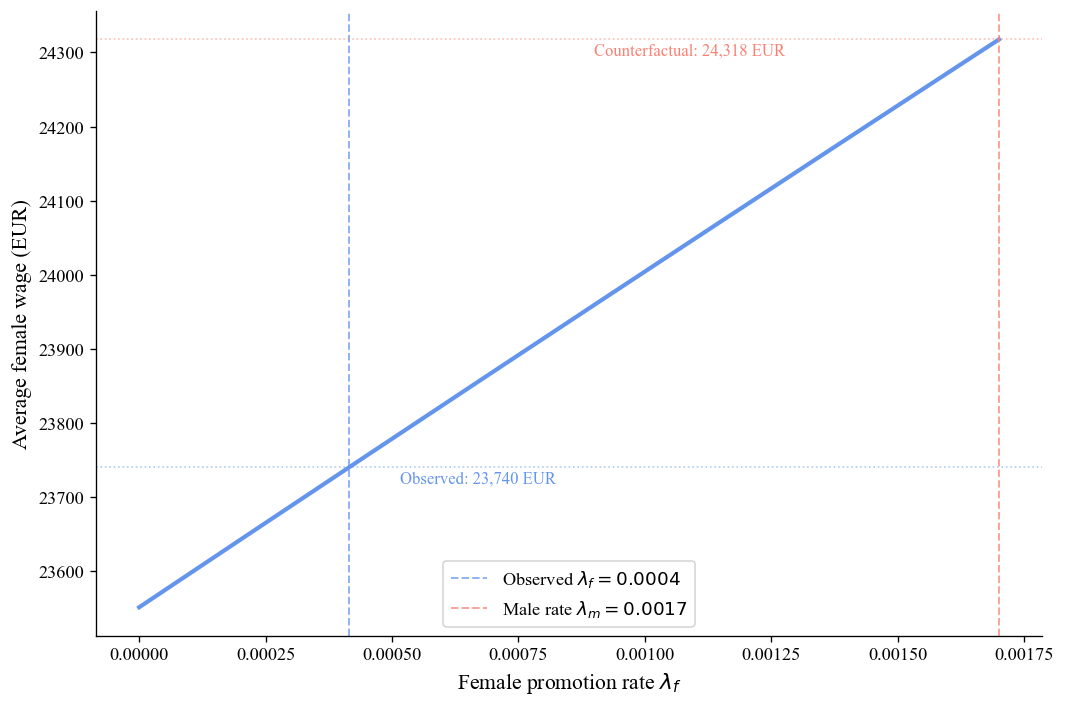

In [63]:
lambda_vec = np.linspace(0, lambda_m, 300)

w_f_vec = np.array([
    (1 - steady_state_f(f_star, lf_val)[2]) * w_E_f + 
    steady_state_f(f_star, lf_val)[2] * w_M_f
    for lf_val in lambda_vec
])

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(lambda_vec, w_f_vec, color='cornflowerblue', lw=2.5)

ax.axvline(lambda_f, color='cornflowerblue', lw=1.2, ls='--', alpha=0.7,
           label=f'Observed $\\lambda_f = {lambda_f:.4f}$')
ax.axvline(lambda_m, color='salmon', lw=1.2, ls='--', alpha=0.7,
           label=f'Male rate $\\lambda_m = {lambda_m:.4f}$')

ax.axhline(w_f_obs, color='cornflowerblue', lw=1.0, ls=':', alpha=0.5)
ax.axhline(w_f_cf, color='salmon', lw=1.0, ls=':', alpha=0.5)
ax.annotate(f'Observed: {w_f_obs:,.0f} EUR',
            xy=(lambda_f, w_f_obs),
            xytext=(lambda_f + 0.0001, w_f_obs -20),
            fontsize=10,
            color='cornflowerblue')

ax.annotate(f'Counterfactual: {w_f_cf:,.0f} EUR',
            xy=(lambda_m, w_f_cf),
            xytext=(lambda_m - 0.0008, w_f_cf - 20),
            fontsize=10,
            color='salmon')


ax.set_xlabel('Female promotion rate $\\lambda_f$', fontsize=13)
ax.set_ylabel('Average female wage (EUR)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('counterfactual_wage.pdf', bbox_inches='tight')
plt.show()


## Deskriptiv statistik 

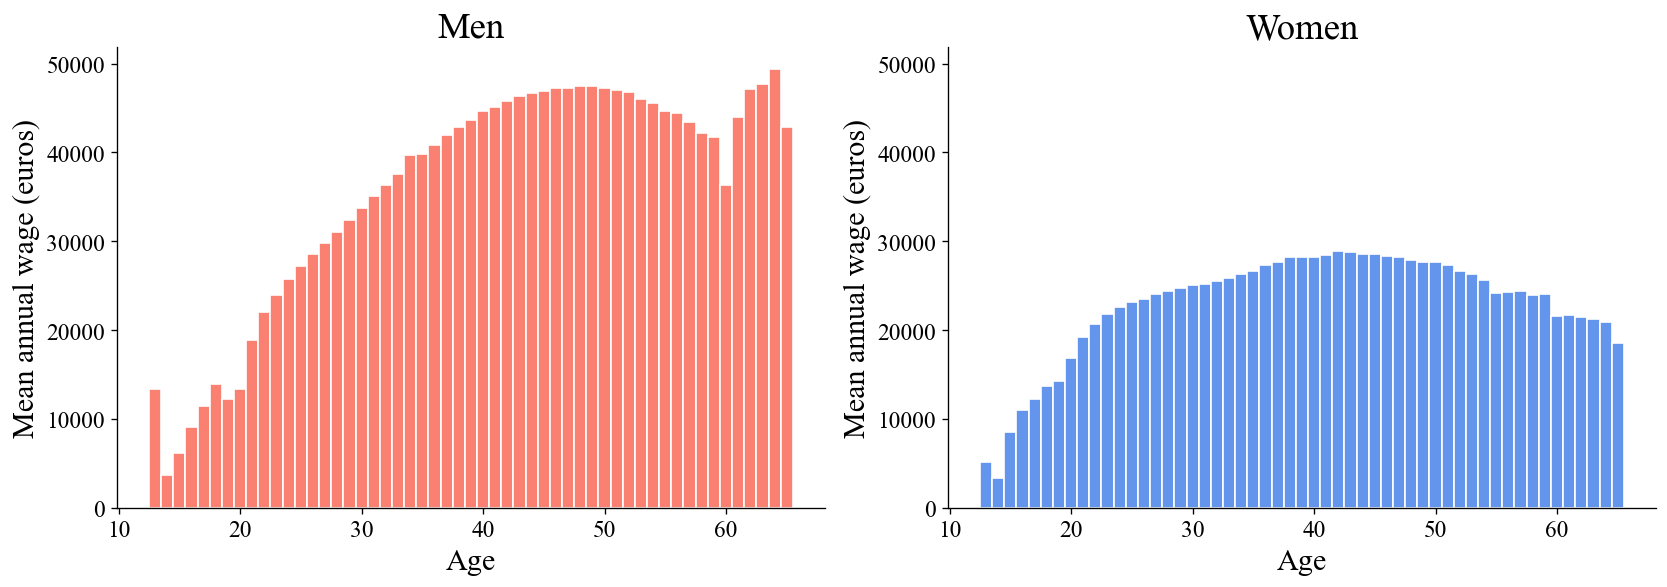

In [71]:
# generer histogrammer over løn fordelt på alder 
wage_by_age_m = df_est[df_est['male']==1].groupby('age')['retrib03'].mean()
wage_by_age_f = df_est[df_est['male']==0].groupby('age')['retrib03'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(wage_by_age_m.index, wage_by_age_m.values, 
            width=1, color='salmon', alpha=1, edgecolor='white')
axes[0].set_xlabel('Age', fontsize=18)
axes[0].set_ylabel('Mean annual wage (euros)', fontsize=18)
axes[0].set_title('Men', fontsize=22)

axes[1].bar(wage_by_age_f.index, wage_by_age_f.values,
            width=1, color='cornflowerblue', alpha=1, edgecolor='white')
axes[1].set_xlabel('Age', fontsize=18)
axes[1].set_ylabel('Mean annual wage (euros)', fontsize=18)
axes[1].set_title('Women', fontsize=22)

y_max = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(0, y_max)
axes[1].set_ylim(0, y_max)
axes[0].tick_params(axis='both', labelsize=14)
axes[1].tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.savefig('wage_age_histogram.pdf', bbox_inches='tight')
plt.show()

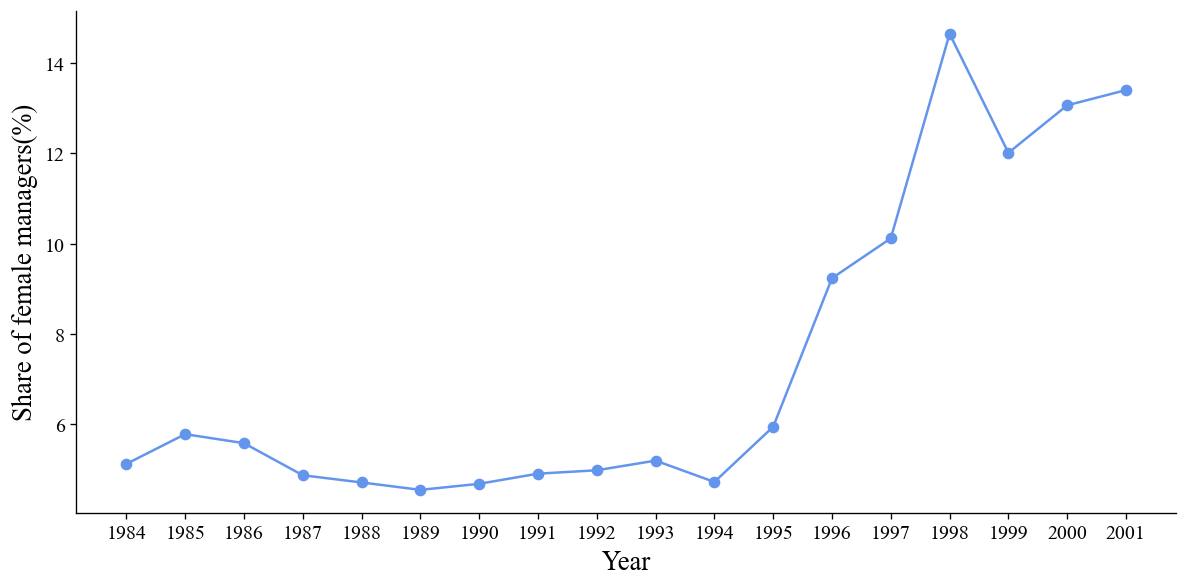

In [36]:
#Andelen af kvindelige managere over tid graf 
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

# Filtrer managers og fjern manglende værdier
managers = df[(df["occupation"] == "Manager") & (df["male"].notna())]

# Grupper på år og køn
managers_by_year_sex = managers.groupby(["year", "male"]).size().unstack()

# Omdøb kolonner
managers_by_year_sex.columns = ["Women", "Men"]

# Beregn andel kvinder
managers_by_year_sex["Share women (%)"] = (
    managers_by_year_sex["Women"] /
    (managers_by_year_sex["Women"] + managers_by_year_sex["Men"]) * 100
)

# Plot
managers_by_year_sex["Share women (%)"].plot(kind="line", marker="o", figsize=(10, 5), color="cornflowerblue", alpha=1)

plt.xlabel("Year", fontsize=16)
plt.ylabel("Share of female managers(%)", fontsize=16)
plt.xticks(range(1984, 2002, 1),fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("share_females_time.pdf", bbox_inches="tight")
plt.show()



### Antallet af managere fordelt på køn over tid 

In [ ]:
# graf over antallet af managere fordelt på køn over tid 
managers_over_tid = (df[df["occupation"] == "Manager"]
                     .groupby(["year", "male"])
                     .size()
                     .reset_index(name="count"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(managers_over_tid[managers_over_tid["male"]==1]["year"],
        managers_over_tid[managers_over_tid["male"]==1]["count"],
        color="salmon", marker="o", lw=2, label="Males")
ax.plot(managers_over_tid[managers_over_tid["male"]==0]["year"],
        managers_over_tid[managers_over_tid["male"]==0]["count"],
        color="cornflowerblue", marker="o",lw=2, label="Females")
ax.set_xlabel("Year", fontsize=16)
ax.set_ylabel("Number of managers", fontsize=16)
ax.legend(fontsize=12)
ax.set_xticks(range(1984, 2002))
ax.tick_params(axis='x', rotation=45)
plt.savefig("managers_over_time.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

### Kvinders alder ved første manager job 

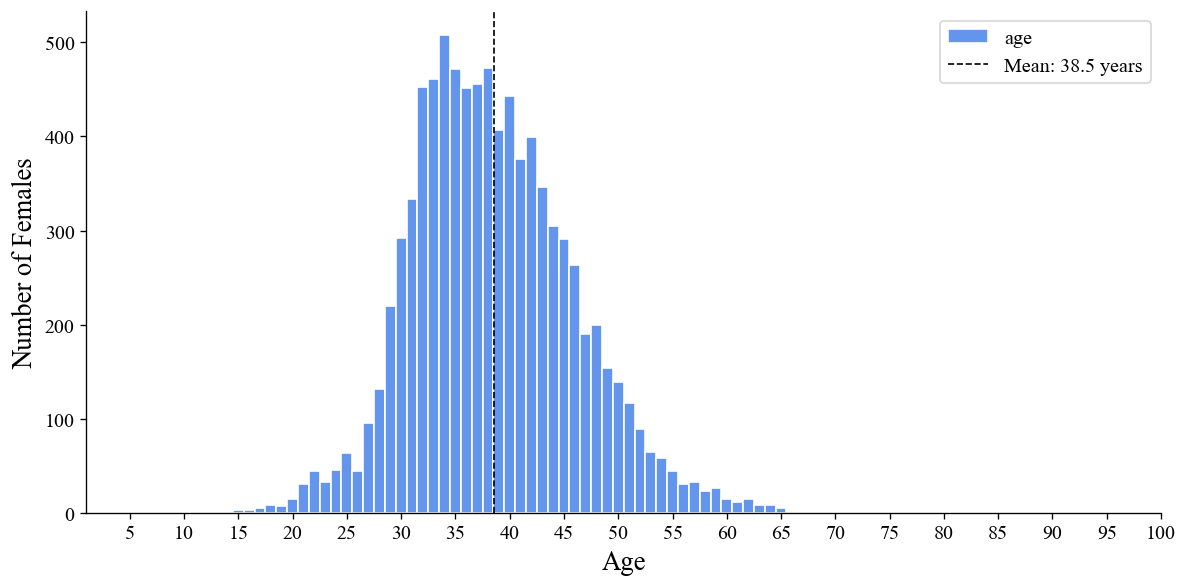

In [66]:
#kvinders alder ved første managerjob
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

# Find første år som manager for hver kvinde
kvinder = df[df["male"] == 0]

første_manager_kvinder = (
    kvinder[kvinder["occupation"] == "Manager"]
    .groupby("id")["year"]
    .min()
    .reset_index()
)

# Filtrer venstrecensurerede observationer
første_obs_kvinder = (kvinder.groupby("id")["year"]
                      .min()
                      .reset_index()
                      .rename(columns={"year": "first_obs_year"}))

første_manager_kvinder = første_manager_kvinder.merge(første_obs_kvinder, on="id")
første_manager_kvinder = første_manager_kvinder[
    første_manager_kvinder["year"] > første_manager_kvinder["first_obs_year"]
]

# Kobl alder på
første_manager_kvinder = første_manager_kvinder.merge(
    kvinder[["id", "year", "age"]],
    on=["id", "year"]
)

# Sørger for at bins er centreret om heltal
min_age = første_manager_kvinder["age"].min()
max_age = første_manager_kvinder["age"].max()
bin_edges = np.arange(min_age - 0.5, max_age + 1.5, 1)

# Graf
første_manager_kvinder["age"].plot(
    kind="hist",
    bins=bin_edges,
    figsize=(10, 5),
    color="cornflowerblue",
    edgecolor="white",
    alpha=1
)
plt.xlabel("Age", fontsize=16)
plt.ylabel("Number of Females", fontsize=16)
plt.xlim(1, 100)
plt.xticks(range(5, 101, 5), fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
mean_age = første_manager_kvinder["age"].mean()
plt.axvline(mean_age, color="black", lw=1, ls="--", label=f"Mean: {mean_age:.1f} years")
plt.legend(fontsize=12)
plt.savefig("females_age.pdf", bbox_inches="tight")
plt.show()



### Mænds alder ved første manager job

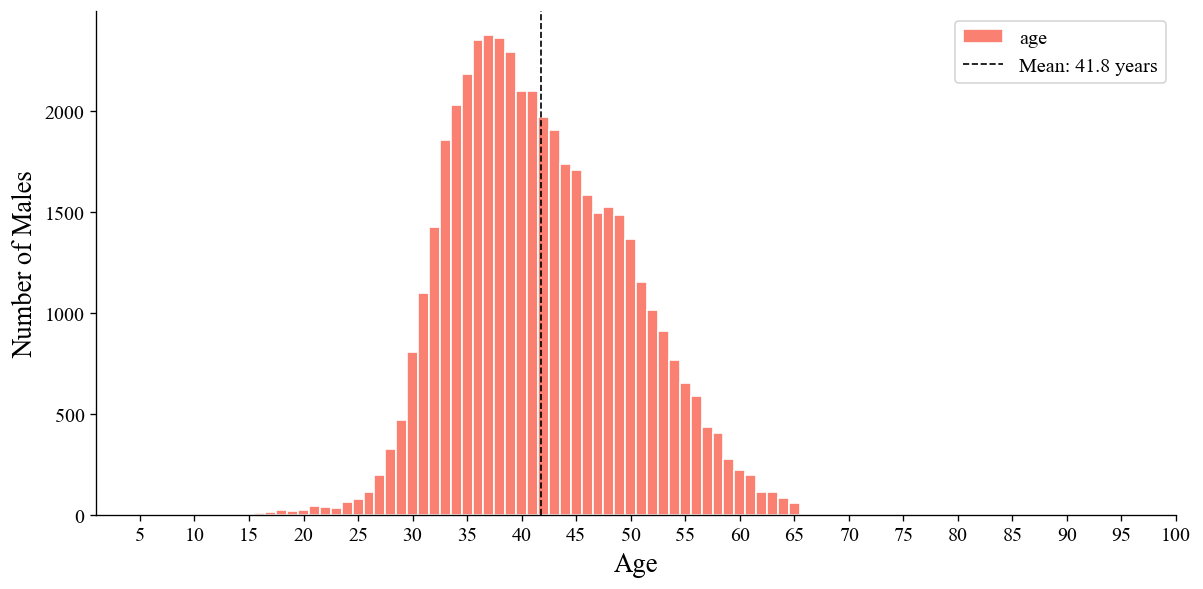

In [65]:
# Find første år som manager for hver mand
mænd = df[df["male"] == 1]

første_manager_mænd = (
    mænd[mænd["occupation"] == "Manager"]
    .groupby("id")["year"]
    .min()
    .reset_index()
)

# Filtrer venstrecensurerede observationer
første_obs_mænd = (mænd.groupby("id")["year"]
                   .min()
                   .reset_index()
                   .rename(columns={"year": "first_obs_year"}))

første_manager_mænd = første_manager_mænd.merge(første_obs_mænd, on="id")
første_manager_mænd = første_manager_mænd[
    første_manager_mænd["year"] > første_manager_mænd["first_obs_year"]
]

# Kobl alder på
første_manager_mænd = første_manager_mænd.merge(
    mænd[["id", "year", "age"]],
    on=["id", "year"]
)

# Bin-kanter ved hvert heltal
min_age = første_manager_mænd["age"].min()
max_age = første_manager_mænd["age"].max()
bin_edges = np.arange(min_age - 0.5, max_age + 1.5, 1)

# Graf
første_manager_mænd["age"].plot(
    kind="hist",
    bins=bin_edges,
    figsize=(10, 5),
    color="salmon",
    edgecolor="white",
    alpha=1
)
plt.xlabel("Age", fontsize=16)
plt.ylabel("Number of Males", fontsize=16)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.xlim(1, 100)
mean_age = første_manager_mænd["age"].mean()
plt.axvline(mean_age, color="black", lw=1, ls="--", label=f"Mean: {mean_age:.1f} years")
plt.xticks(range(5, 101, 5), fontsize=12)
plt.legend(fontsize=12)
plt.savefig("males_age_manager.pdf", bbox_inches="tight")
plt.show()


In [ ]:
print(f'Kontrafaktisk manager-andel kvinder: {mf_nodiscrim:.4f}')
print(f'Observeret manager-andel mænd:       {m_m_data:.4f}')

In [39]:
import statsmodels.formula.api as smf
df_managers = df_est[df_est['manager'] == 1].copy()
# Regression af log løn på køn, alder
# og alder^2 — kun managere
df_managers = df_est[df_est['manager'] == 1].copy()
df_managers['age2'] = df_managers['age'] ** 2

model = smf.ols('log_wage ~ male + age + age2', data=df_managers).fit()
print(model.summary())

w_M_m_log = df_managers[df_managers['male']==1]['log_wage'].mean()
w_M_f_log = df_managers[df_managers['male']==0]['log_wage'].mean()

print(f'\nLøngab uden kontrol for alder:    {w_M_m_log - w_M_f_log:.4f} ({np.exp(w_M_m_log - w_M_f_log)-1:.1%})')
print(f'Løngab med kontrol for alder:     {model.params["male"]:.4f} ({np.exp(model.params["male"])-1:.1%})')


                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                 1.624e+04
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        01:12:19   Log-Likelihood:            -2.5677e+05
No. Observations:              292218   AIC:                         5.135e+05
Df Residuals:                  292214   BIC:                         5.136e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.6203      0.028    271.772      0.0

In [40]:
# Antal år som manager per person
manager_years = (df_est[df_est['manager']==1]
                 .groupby(['id', 'male'])['year']
                 .count()
                 .reset_index()
                 .rename(columns={'year': 'years_as_manager'}))

print('=== Tid som manager ===')
print(f'Mænd — gns. år som manager:   {manager_years[manager_years["male"]==1]["years_as_manager"].mean():.2f}')
print(f'Kvinder — gns. år som manager:{manager_years[manager_years["male"]==0]["years_as_manager"].mean():.2f}')

# T-test for forskel
from scipy.stats import ttest_ind
m = manager_years[manager_years['male']==1]['years_as_manager']
f = manager_years[manager_years['male']==0]['years_as_manager']
t, p = ttest_ind(m, f)
print(f'\nt-statistik: {t:.4f}, p-værdi: {p:.4f}')


=== Tid som manager ===
Mænd — gns. år som manager:   4.72
Kvinder — gns. år som manager:2.84

t-statistik: 43.2235, p-værdi: 0.0000


In [ ]:
# T-test for alder ved første managerjob
from scipy.stats import ttest_ind

m_age = første_manager_mænd['age']
f_age = første_manager_kvinder['age']

t, p = ttest_ind(m_age, f_age)

print(f'Gns. alder mænd:    {m_age.mean():.2f}')
print(f'Gns. alder kvinder: {f_age.mean():.2f}')
print(f't-statistik: {t:.4f}')
print(f'p-værdi:     {p:.4f}')


In [67]:
# n for løngrafer (df_est)
print(f'n observationer (df_est): {len(df_est):,}')
print(f'n unikke individer: {df_est["id"].nunique():,}')
print(f'n unikke mænd: {df_est[df_est["male"]==1]["id"].nunique():,}')
print(f'n unikke kvinder: {df_est[df_est["male"]==0]["id"].nunique():,}')

# n for manager-grafer
print(f'n unikke managere: {df_est[df_est["manager"]==1]["id"].nunique():,}')

# n for alder ved første managerjob
print(f'n kvinder første managerjob: {len(første_manager_kvinder):,}')
print(f'n mænd første managerjob: {len(første_manager_mænd):,}')



n observationer (df_est): 23,971,936
n unikke individer: 2,738,925
n unikke mænd: 1,591,366
n unikke kvinder: 1,147,559
n unikke managere: 65,791
n kvinder første managerjob: 8,705
n mænd første managerjob: 46,226
